In [23]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv


In [13]:
load_dotenv()

True

In [14]:
model = ChatOpenAI()

In [24]:
def call_model(state : MessagesState):
    response = model.invoke(state['messages'])
    return {'messages': response}

In [25]:
builder = StateGraph(MessagesState)

#add node 
builder.add_node('call_model', call_model)
# add edege
builder.add_edge(START, 'call_model')

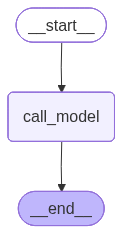

In [26]:
graph = builder.compile()
graph

In [ ]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Rahul."}]})

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='060ee0d1-0626-4351-875c-f6cffc0066d9'),
  AIMessage(content='Hello Nitish! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 15, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DjgycGFrKwCuQovVvJRiOhaIXJEee', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e634b-32c3-7622-8eea-bc00ad6a1e69-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 11, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_t

In [28]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='0c07dadd-2bcc-4d49-8617-a66df5b21d88'),
  AIMessage(content='I am sorry, I do not have access to personal information about users.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 12, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DjgyuCcpl40j5rMs1F21ZZdk5u6DO', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e634b-7a3a-7c93-91dc-9a3c3b73aac2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 15, 'total_tokens': 27, 'input_token_details': {'audio': 0, 'cach

### Checkpointer

In [29]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [30]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")


In [31]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [32]:
config = {"configurable": {"thread_id": "thread-1"}}

In [33]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Rahul."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Rahul.', additional_kwargs={}, response_metadata={}, id='b7f2f815-ee36-4416-a7cf-54ed38ce1c9d'),
  AIMessage(content='Hi Rahul! Nice to meet you. How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 14, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DjgzsGPshf722VOdhmm5J3OEYnYa1', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e634c-6679-7373-9ed9-be42a5eae842-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 15, 'total_tokens': 29, 'input_token_details': {'audio': 0, 'cache_read': 

In [34]:

graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config=config)

{'messages': [HumanMessage(content='Hi! My name is Rahul.', additional_kwargs={}, response_metadata={}, id='b7f2f815-ee36-4416-a7cf-54ed38ce1c9d'),
  AIMessage(content='Hi Rahul! Nice to meet you. How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 14, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DjgzsGPshf722VOdhmm5J3OEYnYa1', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e634c-6679-7373-9ed9-be42a5eae842-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 15, 'total_tokens': 29, 'input_token_details': {'audio': 0, 'cache_read': 

In [35]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Rahul.
- AIMessage : Hi Rahul! Nice to meet you. How can I assist you today?
- HumanMessage : What is my name?
- AIMessage : Your name is Rahul.
